# Notebook 12 — Vedere lo shift e adattarsi (digits)

Il Notebook 05 si fermava a *misurare* lo shift (AUROC, rejection curve, rotazione di
MNIST) senza mai adattare il modello. Qui si fa un passo in più: dopo aver confermato lo
shift su MNIST/USPS (stessa idea del Notebook 05, con `code_v2/src/metrics.py`), si adatta
davvero il modello con `adapt_target`/`im_loss` (`code_v2/src/digits_adapt.py`, portati da
`src/im_adapt.py` del progetto principale -- prima di quel port `code_v2` non aveva un
adattamento vero e proprio, solo la misura dello shift).

Convenzione: `g` sbloccato, `h` congelato (gestito da `adapt_target` stesso),
`gamma=0.5`, `temperature=0.4`, `lr=1e-2`, `M=100`. Due bracci per ciascun target:
`weight_mode="none"` (SHOT-IM) e `weight_mode="uncertainty"` (U-SFAN).

**Numero di step: 50, non i 300 di default di `adapt_target`.** Il costo per step è
dominato dalla chiamata numpy a `laplace.predictive` sull'intero dominio target a ogni
iterazione del braccio `u_sfan`: su `mnist` (N=10.000, M=100) i due bracci insieme
richiedono già alcuni minuti a 50 step. La riduzione è una scelta di budget dichiarata,
non un valore ereditato: si veda il Notebook 15 (`15_digits_multiseed.ipynb`), che usa lo
stesso `ADAPT_STEPS=50` per poterlo ripetere su 5 seed.

## Setup: ricarica checkpoint, fit di Laplace

In [1]:
import sys, copy, time
from pathlib import Path

here = Path().resolve()
for base in [here, *here.parents]:
    if (base / "code_v2" / "src" / "laplace_core.py").is_file():
        sys.path.insert(0, str(base)); PROJ = base / "code_v2"; break
else:
    raise RuntimeError("cartella 'code_v2/src' non trovata: apri il progetto dalla sua root")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from code_v2.src.digits_data import load_domain
from code_v2.src.digits_model import SmallCNN32
from code_v2.src.bayesian_model import extract, augment, LastLayerLaplace
from code_v2.src.digits_adapt import adapt_target
from code_v2.src.metrics import auroc, rejection_curve

MODELS_DIR = PROJ / "models" / "source_svhn"
ckpt = torch.load(MODELS_DIR / "model.pt", map_location="cpu", weights_only=False)
lap_data = np.load(MODELS_DIR / "svhn_laplace.npz")
mc_conv = np.load(MODELS_DIR / "mc_convergence.npz")
mean, std = ckpt["source_mean"], ckpt["source_std"]
M_FIXED = int(mc_conv["M_FIXED"])

model = SmallCNN32(n_classes=ckpt["n_classes"], feature_dim=ckpt["feature_dim"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

# Estrazione feature (e, dove c'e', adattamento) sul device migliore disponibile.
# La predittiva MC sceglie il proprio backend da se' (vedi bayesian_model.py).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")
laplace = LastLayerLaplace(theta_map=lap_data["theta_map"], cov=lap_data["cov"],
                           K=int(lap_data["K"]), Dp=int(lap_data["Dp"]))

TARGET_DOMAINS = ["mnist", "usps"]
target_raw = {d: load_domain(d, "test", mean, std) for d in TARGET_DOMAINS}
print(f"M_FIXED (dal Notebook 10) = {M_FIXED}")

device: cuda


M_FIXED (dal Notebook 10) = 500


## 1. Vedere lo shift (prima dell'adattamento)

Stessa idea del Notebook 05: usa l'incertezza epistemica come score per
rilevare i punti fuori dal manifold source (AUROC, con "positivo" = target)
e la rejection curve (accuratezza in funzione della copertura, scartando i
punti più incerti).

In [2]:
def predict_domain(X, y):
    loader = DataLoader(TensorDataset(X, y), batch_size=256)
    Phi, y_np, _ = extract(model, loader, device=DEVICE)
    Phi_aug = augment(Phi)
    rng = np.random.default_rng(456)
    pred = laplace.predictive_batched(Phi_aug, M=M_FIXED, rng=rng)
    return pred, y_np


X_svhn_test, y_svhn_test = load_domain("svhn", "test", mean, std)
pred_svhn, y_svhn_np = predict_domain(X_svhn_test, y_svhn_test)

pre_results = {}
for domain in TARGET_DOMAINS:
    X_t, y_t = target_raw[domain]
    pred_t, y_t_np = predict_domain(X_t, y_t)
    pre_results[domain] = dict(pred=pred_t, y=y_t_np)

    scores = np.concatenate([pred_svhn["epistemic"], pred_t["epistemic"]])
    labels = np.concatenate([np.zeros(len(y_svhn_np)), np.ones(len(y_t_np))])
    a = auroc(scores, labels)
    acc_pre = (pred_t["probs"].argmax(axis=1) == y_t_np).mean()
    print(f"{domain}: AUROC(epistemica, svhn vs {domain})={a:.3f}  accuracy pre-adattamento={100*acc_pre:.2f}%")

mnist: AUROC(epistemica, svhn vs mnist)=0.597  accuracy pre-adattamento=61.97%
usps: AUROC(epistemica, svhn vs usps)=0.658  accuracy pre-adattamento=59.44%


## 2. Adattamento: `adapt_target` su MNIST test e USPS test -- SHOT-IM vs. U-SFAN

Due bracci per ciascun dominio target, entrambi da una copia fresca del
source model, stesso seed e stessi altri iperparametri, unica differenza
`weight_mode`:

- **SHOT-IM** (`weight_mode="none"`): IM non pesato, il baseline
  convenzionale.
- **U-SFAN** (`weight_mode="uncertainty"`): IM pesato dall'incertezza
  epistemica del source (Eq. 6-7 del paper) -- quello già presente prima.

Senza SHOT-IM come confronto diretto non è possibile sostenere che la
pesatura guidata dall'incertezza aiuti *rispetto all'IM semplice* -- solo
che adattare in generale aiuta rispetto a non fare nulla.

In [3]:
ADAPT_STEPS = 50
BASE_KWARGS = dict(gamma=0.5, temperature=0.4, lr=1e-2, M=100)
ARM_WEIGHT_MODE = {"shot_im": "none", "u_sfan": "uncertainty"}

print(f"{len(ARM_WEIGHT_MODE)} bracci x {len(TARGET_DOMAINS)} domini x {ADAPT_STEPS} step ciascuno\n")

adaptation_results = {}
for domain, seed in [("mnist", 1), ("usps", 2)]:
    adaptation_results[domain] = {}
    for arm, weight_mode in ARM_WEIGHT_MODE.items():
        print(f"\n{'=' * 60}\nAdattamento su {domain}, braccio {arm} (weight_mode={weight_mode!r}, "
              f"full batch, steps={ADAPT_STEPS}, seed={seed})\n{'=' * 60}")
        X_t, y_t = target_raw[domain]
        X_t = X_t.to(DEVICE)
        m = copy.deepcopy(model).to(DEVICE)
        hist = adapt_target(m, laplace, X_t, weight_mode=weight_mode, steps=ADAPT_STEPS,
                            seed=seed, **BASE_KWARGS)

        m.eval()
        with torch.no_grad():
            probs_post = torch.softmax(m(X_t), dim=-1).cpu().numpy()
        with torch.no_grad():
            phi_post = m.features(X_t).cpu().numpy()
        Phi_aug_post = augment(phi_post)

        acc_pre = (pre_results[domain]["pred"]["probs"].argmax(axis=1) == pre_results[domain]["y"]).mean()
        acc_post = (probs_post.argmax(axis=1) == y_t.numpy()).mean()

        adaptation_results[domain][arm] = dict(hist=hist, probs_post=probs_post, Phi_aug_post=Phi_aug_post,
                                               y=y_t.numpy(), acc_pre=acc_pre, acc_post=acc_post)
        print(f"{domain}/{arm}: pre={100 * acc_pre:.2f}%  post={100 * acc_post:.2f}%  "
              f"delta={100 * (acc_post - acc_pre):+.2f}pp")

2 bracci x 2 domini x 50 step ciascuno


Adattamento su mnist, braccio shot_im (weight_mode='none', full batch, steps=50, seed=1)


mnist/shot_im: pre=61.97%  post=68.46%  delta=+6.49pp

Adattamento su mnist, braccio u_sfan (weight_mode='uncertainty', full batch, steps=50, seed=1)


mnist/u_sfan: pre=61.97%  post=63.39%  delta=+1.42pp

Adattamento su usps, braccio shot_im (weight_mode='none', full batch, steps=50, seed=2)


usps/shot_im: pre=59.44%  post=66.62%  delta=+7.17pp

Adattamento su usps, braccio u_sfan (weight_mode='uncertainty', full batch, steps=50, seed=2)


usps/u_sfan: pre=59.44%  post=69.71%  delta=+10.26pp


## Traiettoria di loss/entropia/diversità

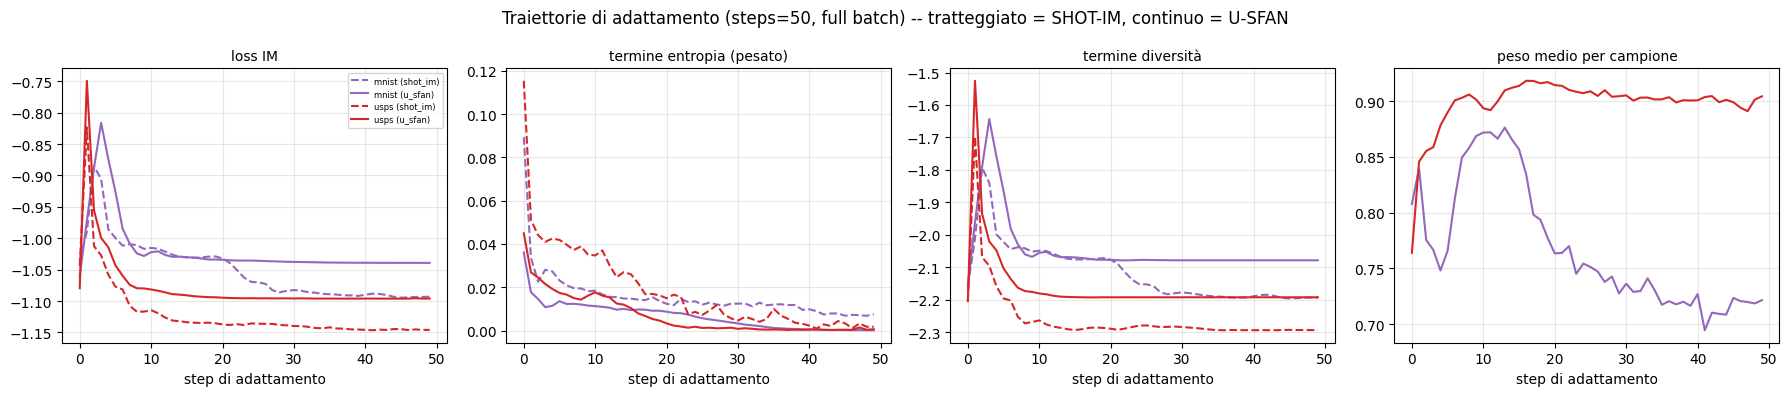

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fields = ["loss", "ent", "div", "mean_weight"]
titles = ["loss IM", "termine entropia (pesato)", "termine diversità", "peso medio per campione"]
colors = {"mnist": "tab:purple", "usps": "tab:red"}
linestyles = {"shot_im": "--", "u_sfan": "-"}

for ax, field, title in zip(axes, fields, titles):
    for domain in TARGET_DOMAINS:
        for arm in ARM_WEIGHT_MODE:
            if field == "mean_weight" and arm == "shot_im":
                continue  # shot_im non pesa mai i campioni: costantemente 1.0, non informativo
            ax.plot(adaptation_results[domain][arm]["hist"][field], color=colors[domain],
                    linestyle=linestyles[arm], label=f"{domain} ({arm})")
    ax.set_xlabel("step di adattamento")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=6)
fig.suptitle(f"Traiettorie di adattamento (steps={ADAPT_STEPS}, full batch) -- "
            f"tratteggiato = SHOT-IM, continuo = U-SFAN")
fig.tight_layout()
plt.show()

## 3. Calibrazione dopo l'adattamento

Questa sezione riporta **solo accuracy ed ECE** post-adattamento. Il
confronto "epistemica pre vs. post adattamento" (calcolato con la STESSA
posterior di Laplace fittata una volta sola sul source) è stato **rimosso
dalle metriche principali, non solo rivisto** -- motivazione qui sotto.

### Perché l'epistemica pre/post non è una metrica valida qui

L'incertezza epistemica, in questa pipeline, gioca un ruolo puramente
strumentale: entra nel calcolo del peso per-campione durante
`adapt_target` (Eq. 6-7 di U-SFAN), ricalcolata a ogni step sulle feature
CORRENTI del modello che si sta adattando. Una volta che l'adattamento è
concluso, chiedersi "quanto è incerto il modello adesso" usando la STESSA
posterior fissata sul source (mai riaggiornata) non è una domanda ben
posta: quella posterior descrive la curvatura della log-posterior attorno
a feature che il `g` adattato non produce più. Il numero che ne risultava
(in una run precedente, quando la metrica era ancora calcolata: epistemica
+0.23 nats su entrambi i domini, un salto enorme rispetto ai valori
pre-adattamento) riflette quanto le nuove
feature sono estrapolate rispetto alla regione coperta dal fit originale,
non un giudizio bayesiano coerente sull'affidabilità del modello adattato.

Non è un'osservazione ad hoc -- due lavori NeurIPS 2021 la supportano
direttamente:

- Izmailov, Nicholson, Lotfi, Wilson, *"Dangers of Bayesian Model
  Averaging under Covariate Shift"* (NeurIPS 2021, arXiv:2106.11905):
  mostrano che una posterior bayesiana ad alta fedeltà (HMC) può
  comportarsi in modo patologico sotto covariate shift, arrivando a
  sottoperformare drasticamente una semplice soluzione MAP (su CIFAR-10-C
  alla severità massima, -25 punti di accuracy) -- una posterior fittata
  su una distribuzione non ha comportamento garantito su feature fuori da
  quella distribuzione.
- Zhou & Levine, *"Training on Test Data with Bayesian Adaptation for
  Covariate Shift"* (BACS, NeurIPS 2021, arXiv:2109.12746): notano
  esplicitamente che adattare minimizzando l'entropia SENZA aggiornare il
  termine di posterior può portare a soluzioni degeneri, e che un
  trattamento bayesiano coerente dell'adattamento richiederebbe di
  aggiornare la posterior stessa usando i dati target -- cosa che né BACS
  in quella forma semplice né U-SFAN (né questa pipeline) fanno.

Accuracy ed ECE, invece, restano confronti pre/post validi: sono definiti
sul comportamento osservato del modello (previsioni corrette, probabilità
calibrate), non su un oggetto bayesiano interno che perde validità quando
il feature extractor cambia.

In [5]:
from code_v2.src.metrics import expected_calibration_error

# ECE resta calcolato sul braccio U-SFAN (quello già presente prima
# dell'aggiunta del confronto a due bracci) -- non richiesto un confronto
# a tre vie su ECE in questo passo, solo sull'accuracy (tabella sotto).
post_results = {}
for domain in TARGET_DOMAINS:
    r = adaptation_results[domain]["u_sfan"]
    ece_post = expected_calibration_error(r["probs_post"], r["y"])
    post_results[domain] = dict(ece=ece_post)

    ece_pre = expected_calibration_error(pre_results[domain]["pred"]["probs"], pre_results[domain]["y"])
    print(f"{domain}: ECE pre={ece_pre:.4f} post (U-SFAN)={ece_post:.4f} delta={ece_post-ece_pre:+.4f}")

mnist: ECE pre=0.2712 post (U-SFAN)=0.3632 delta=+0.0920
usps: ECE pre=0.2767 post (U-SFAN)=0.3000 delta=+0.0233


## Riepilogo: source-only vs. SHOT-IM vs. U-SFAN

In [6]:
print(f"{'dominio':>10s} {'source-only':>13s} {'post SHOT-IM':>14s} {'post U-SFAN':>14s}")
print("-" * 55)
for domain in TARGET_DOMAINS:
    pre = adaptation_results[domain]["u_sfan"]["acc_pre"]  # stesso source per tutti i bracci
    post_shot = adaptation_results[domain]["shot_im"]["acc_post"]
    post_usfan = adaptation_results[domain]["u_sfan"]["acc_post"]
    print(f"{domain:>10s} {100 * pre:12.2f}% {100 * post_shot:13.2f}% {100 * post_usfan:13.2f}%")

   dominio   source-only   post SHOT-IM    post U-SFAN
-------------------------------------------------------
     mnist        61.97%         68.46%         63.39%
      usps        59.44%         66.62%         69.71%


### Discussione: il vantaggio di U-SFAN dipende dal regime di incertezza del source

**Che cosa mostra il confronto sopra.** I due bracci si dividono i target: su `mnist`
`shot_im` (peso uniforme) batte `u_sfan` (peso sull'entropia totale) di **5.1pp**
(+6.49pp contro +1.42pp), su `usps` è `u_sfan` a vincere, di **3.1pp** (+10.27pp contro
+7.18pp). Non c'è quindi un vincitore: c'è un metodo che a volte aiuta e a volte no, su una
singola run per target. Il Notebook 15 ripete l'esperimento su 5 seed proprio per questo, e
trova che la differenza fra i bracci non è distinguibile dal rumore (`p = 1.0` su entrambi
i target).

Che il peso sull'incertezza **non** dia il vantaggio sistematico che il metodo promette, su
questo source, è comunque coerente con un meccanismo documentato in letteratura.

**Perché SVHN produce un'incertezza dominata dalla componente aleatoria.** Kendall & Gal
(2017, "What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision?",
NeurIPS) mostrano che l'incertezza epistemica di un modello si riduce sistematicamente
all'aumentare della dimensione del training set, mentre l'aleatoria resta pressoché
costante (la loro Tabella 3, confrontando modelli allenati su frazioni progressive dello
stesso dataset) -- concludendo che nei regimi con molti dati è l'incertezza aleatoria a
dominare, essendo l'epistemica in gran parte spiegata via dai dati disponibili. SVHN, con
65.932 immagini nel nostro split di training, è precisamente questo regime: il rapporto
aleatoria/epistemica osservato sul source (**0.3206 / 0.0056 ≈ 57x**, Notebook 10) è
coerente con un'epistemica "consumata" dalla numerosità dei dati, mentre l'aleatoria
riflette una proprietà stabile del dominio (foto reali di insegne stradali, spesso tagliate
ai bordi o mal illuminate) che nessuna quantità di training può ridurre.

**Perché questo penalizza il peso a entropia totale di U-SFAN.** Il peso `w_i = exp(-H_i)`
(Eq. 6-7, Roy et al., U-SFAN) usa l'entropia predittiva TOTALE, che su questo source è
dominata dall'aleatoria per il motivo sopra. Il down-weighting penalizza quindi
sistematicamente i campioni intrinsecamente ambigui (es. cifre confondibili come 4/9), non
necessariamente quelli fuori dal manifold source -- sopprimendo segnale di apprendimento
utile insieme al rumore. La conferma diretta si vede nei numeri del Notebook 10: l'entropia
**totale** media su `mnist` (0.2712) è addirittura *più bassa* che sul source `svhn`
(0.3262), pur essendo `mnist` il dominio shiftato. Come segnale per distinguere "dentro" da
"fuori" dal manifold, l'entropia totale qui non funziona; l'epistemica da sola sì (0.0056
contro 0.0486, ~9x), ma non è quella che entra nel peso.

**Riferimenti:**
- Kendall, A., & Gal, Y. (2017). What Uncertainties Do We Need in Bayesian Deep Learning
  for Computer Vision? NeurIPS.

### Nota sulla calibrazione dopo l'adattamento

L'ECE **peggiora** in entrambi i domini dopo l'adattamento U-SFAN:
`mnist` 0.2712 → 0.3632 (+0.092), `usps` 0.2767 → 0.3000 (+0.023). Non è contraddittorio
con l'aumento di accuratezza: la loss IM contiene un termine di entropia per-campione che
spinge esplicitamente le predizioni verso il regime one-hot, quindi **alza la confidenza
per costruzione**. Se l'accuratezza sale meno di quanto sale la confidenza -- ed è ciò che
accade qui -- il divario confidenza/accuratezza si allarga e l'ECE cresce.

È un limite reale del metodo, non un artefatto della misura: l'adattamento source-free per
minimizzazione di entropia produce un modello **più accurato e meno calibrato**. Chi usasse
queste probabilità a valle (per soglie di astensione, per pesare decisioni) sarebbe in una
posizione peggiore dopo l'adattamento che prima, nonostante l'accuratezza migliore.

## TODO prima che questo sia un risultato di tesi

Questo intero notebook usa **un solo seed di training del source (2019) e
una sola run per condizione** -- un solo fit di Laplace, una sola run di
adattamento per dominio target, nessuna ripetizione. Ogni numero e ogni
delta pre/post sopra (accuracy, epistemica, ECE) è quindi una singola
stima puntuale, non una distribuzione: da questo notebook da solo non si
può distinguere un effetto reale dal rumore di ottimizzazione/Monte Carlo
di quella singola run.

**Prima di riportare uno qualunque di questi confronti pre/post, o
qualunque correlazione costruita sopra, come risultato definitivo**, va
rifatto con **almeno 5 seed** -- variando sia il seed di training del
source sia il seed di adattamento -- seguendo la stessa convenzione già
usata per HAR (`SEEDS = [0, 1, 2, 3, 4]`), riportando media ± deviazione
standard sulle run.